# Decision Tree

### Pros
- Interpretability
- Non-linear relationships
- No feature scaling required
- Handles both numerical and categorical data
- Robust to outliers

### Cons
- Overfitting
- High variance
- Instability
- Bias towards features with many levels
- Difficulty in capturing linear relationships

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, 
    recall_score, precision_score, roc_auc_score
)
from sklearn.tree import plot_tree
from sklearn.feature_selection import RFE

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.over_sampling import ADASYN

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Using Correlation as Feature Selection

<Axes: >

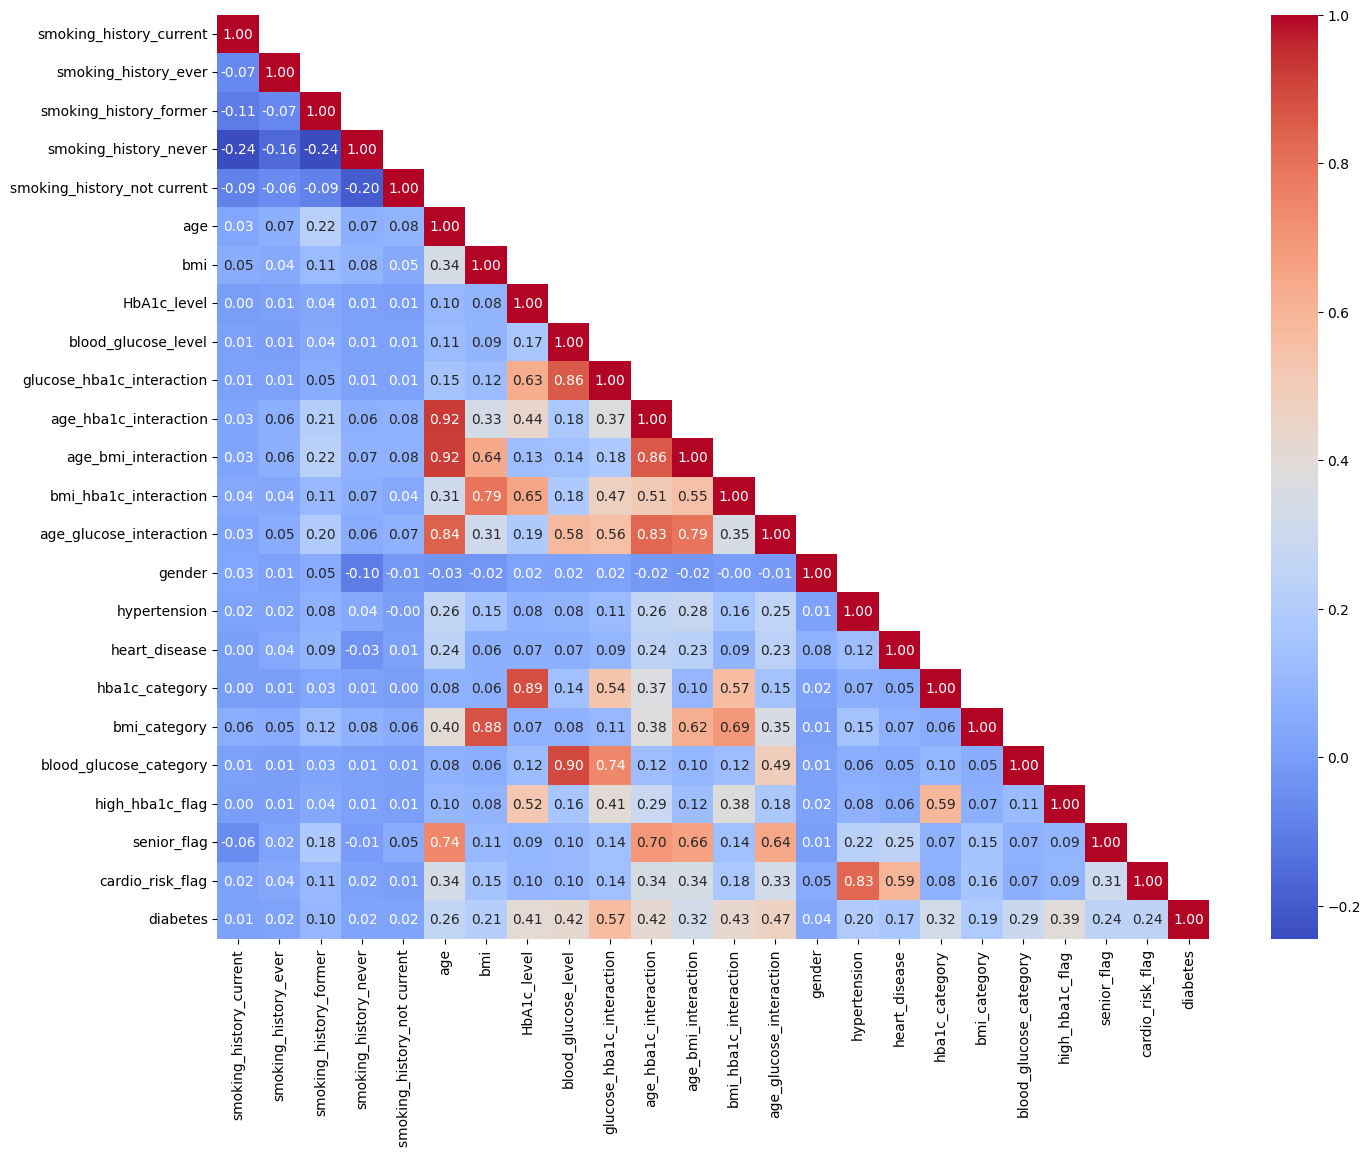

In [40]:
train_preprocessed_df = pd.read_csv("../../data/preprocessed/train_preprocessed.csv") 
validation_preprocessed_df = pd.read_csv("../../data/preprocessed/validation_preprocessed.csv") 

corr_matrix = train_preprocessed_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt=".2f")

### Feature selection Using Correlation

when two features have high correlation remove the one with lower correlation with target

- remove age vs keeping (age_hba1c_interaction , age_bmi_interaction and age_glucose_interaction )
- remove blood_glucose_level vs keeping (glucose_hba1c_interaction)
- remove age_bmi_interaction vs keeping (age_hba1c_interaction) 
- remove age_hba1c_interaction vs keeping ( age_glucose_interaction )
- remove hypertension vs keeping (cardio_flag_risk)
- remove bmi_category vs keeping (bmi)
- remove hba1c_category vs keeping (HbA1C_level)
- remove blood_glucose_category vs keeping (blood_glucose_level)

In [41]:
corr_matrix = corr_matrix.abs()  # abs() catches negative correlations too

upper_triangle = corr_matrix.where(mask.astype(bool))

to_drop = [
    "age",
    "blood_glucose_level",
    "age_bmi_interaction",
    "age_hba1c_interaction",
    "hypertension",
    "bmi_category",
    "hba1c_category",
    "blood_glucose_category"
]

print(f"Features to drop: {to_drop}")

cleared = train_preprocessed_df.drop(columns=to_drop)
print(f"Remaining features: {cleared.columns.tolist()}")

Features to drop: ['age', 'blood_glucose_level', 'age_bmi_interaction', 'age_hba1c_interaction', 'hypertension', 'bmi_category', 'hba1c_category', 'blood_glucose_category']
Remaining features: ['smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'bmi', 'HbA1c_level', 'glucose_hba1c_interaction', 'bmi_hba1c_interaction', 'age_glucose_interaction', 'gender', 'heart_disease', 'high_hba1c_flag', 'senior_flag', 'cardio_risk_flag', 'diabetes']


In [42]:
y_train = cleared['diabetes'].copy()
X_train = cleared.drop('diabetes', axis=1)


y_test = validation_preprocessed_df['diabetes'].copy()
X_test = validation_preprocessed_df.drop('diabetes', axis=1)

# Align test to train columns exactly
X_test = X_test[X_train.columns]

In [43]:
def decision_tree_training(X_train, y_train, X_test, y_test):
    # train
    dt_model = DecisionTreeClassifier(
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    )
    
    dt_model.fit(X_train, y_train)
    
    # predict
    
    y_pred = dt_model.predict(X_test)
    # [0.8 no diabetes , 0.2 diabetes]
    y_prob = dt_model.predict_proba(X_test)[:, 1]
    
    # metrics
    accuracy  = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)      # business metric — catches diabetics
    precision = precision_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)

    print(classification_report(y_test, y_pred))
    

### Trying model

- precision — of everyone we predicted as diabetic, how many actually were?
- recall — of all actual diabetics, how many did we correctly catch? (More Focus)
- f1-score — balance between precision and recall
- accuracy — overall correctness across all samples (not the metric-  Misleading with imbalanced data!)

In [44]:
# normal dataset 
print("====== Normal DataSet ======\n\n")
decision_tree_training(X_train, y_train, X_test, y_test)

====== Normal DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.91      0.95     13115
           1       0.49      0.85      0.62      1272

    accuracy                           0.91     14387
   macro avg       0.74      0.88      0.78     14387
weighted avg       0.94      0.91      0.92     14387



- Recall : Out of every 100 actual diabetic patients
your model correctly identified 85 of them
and missed 15 (Good)

- Precision = 0.49 → only 49% of predicted diabetics actually are (bad)

- F1 = 0.62 → poor balance between precision and recall 

→ Casts a wide net
→ Catches more diabetics (high recall)
→ But too many false alarms (low precision)

gave poor prediction

In [45]:
# trying with smote
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("====== SMOTE DataSet ======\n\n")
decision_tree_training(X_train_res, y_train_res, X_test, y_test)

====== SMOTE DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.97      0.97     13115
           1       0.70      0.76      0.73      1272

    accuracy                           0.95     14387
   macro avg       0.84      0.86      0.85     14387
weighted avg       0.95      0.95      0.95     14387



- Recall : Out of every 0.76 actual diabetic patients
your model correctly identified 76 of them
and missed 24 (less good)

- Precision = 0.70 → only 70% of predicted diabetics actually are (bad)

- F1 = 0.73 →  give better balance between precision and  Recall

- → More conservative
- → Misses more diabetics (lower recall)
- → But more accurate when it does predict diabetic (higher precision)
- → Better overall balance (higher F1)

In [46]:
# trying with smote tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_s_tomek, y_train_s_tomek = smote_tomek.fit_resample(X_train, y_train)
print("====== SMOTE Tomek DataSet ======\n\n")
decision_tree_training(X_train_s_tomek, y_train_s_tomek, X_test, y_test)

====== SMOTE Tomek DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.96      0.97     13115
           1       0.68      0.76      0.72      1272

    accuracy                           0.95     14387
   macro avg       0.83      0.86      0.84     14387
weighted avg       0.95      0.95      0.95     14387



→ Cleaner boundaries helped precision significantly
→ Slight recall drop = 115 more missed diabetics
→ Best overall balance

In [47]:
# trying with smote ENN
smote_enn = SMOTEENN(random_state=42)
X_train_s_enn, y_train_s_enn = smote_enn.fit_resample(X_train, y_train)
print("====== SMOTE ENN DataSet ======\n\n")
decision_tree_training(X_train_s_enn, y_train_s_enn, X_test, y_test)

====== SMOTE ENN DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.93      0.96     13115
           1       0.53      0.85      0.66      1272

    accuracy                           0.92     14387
   macro avg       0.76      0.89      0.81     14387
weighted avg       0.94      0.92      0.93     14387



→ Aggressive cleaning maintained recall
→ But precision barely improved
→ Least effective of the three

In [48]:
# trying with ADASYN
adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)
print("====== ADAYSYN DataSet ======\n\n")
decision_tree_training(X_train_ada, y_train_ada, X_test, y_test)

====== ADAYSYN DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.96      0.97     13115
           1       0.67      0.77      0.72      1272

    accuracy                           0.95     14387
   macro avg       0.82      0.87      0.84     14387
weighted avg       0.95      0.95      0.95     14387



ADASYN is A good compormise between more false alarms and more missed diabettes

In [49]:
def do_all(X_train, y_train, X_test, y_test):
    # normal dataset 
    print("====== Normal DataSet ======\n\n")
    decision_tree_training(X_train, y_train, X_test, y_test)
    
    # trying with smote
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("====== SMOTE DataSet ======\n\n")
    decision_tree_training(X_train_res, y_train_res, X_test, y_test)
    
    # trying with smote tomek
    smote_tomek = SMOTETomek(random_state=42)
    X_train_s_tomek, y_train_s_tomek = smote_tomek.fit_resample(X_train, y_train)
    print("====== SMOTE Tomek DataSet ======\n\n")
    decision_tree_training(X_train_s_tomek, y_train_s_tomek, X_test, y_test)
    
    
    # trying with smote ENN
    smote_enn = SMOTEENN(random_state=42)
    X_train_s_enn, y_train_s_enn = smote_enn.fit_resample(X_train, y_train)
    print("====== SMOTE ENN DataSet ======\n\n")
    decision_tree_training(X_train_s_enn, y_train_s_enn, X_test, y_test)
    
    # trying with ADASYN
    adasyn = ADASYN(random_state=42)
    X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)
    print("====== ADAYSYN DataSet ======\n\n")
    decision_tree_training(X_train_ada, y_train_ada, X_test, y_test)

In [54]:
def dt_with_rfe(X_train, y_train, X_test, y_test):
    dt_base = DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    )
    
    rfe = RFE(
        estimator=dt_base,
        n_features_to_select=8,  # start with 10, we will tune this
        step=1                     # remove 1 feature at a time
    )

    rfe.fit(X_train, y_train)
    
    feature_ranking = pd.DataFrame({
        'feature' : X_train.columns,
        'selected': rfe.support_,    # True/False
        'ranking' : rfe.ranking_     # 1 = selected, higher = removed earlier
    }).sort_values('ranking')

    print("Selected features:")
    print(feature_ranking[feature_ranking['selected'] == True])

    print("\nRemoved features:")
    print(feature_ranking[feature_ranking['selected'] == False])
    
    X_train_rfe = rfe.transform(X_train)
    X_test_rfe  = rfe.transform(X_test)

    do_all(X_train_rfe, y_train, X_test_rfe, y_test)

In [55]:
y_train = train_preprocessed_df['diabetes'].copy()
X_train = train_preprocessed_df.drop('diabetes', axis=1)


y_test = validation_preprocessed_df['diabetes'].copy()
X_test = validation_preprocessed_df.drop('diabetes', axis=1)

dt_with_rfe(X_train, y_train, X_test, y_test)

Selected features:
                      feature  selected  ranking
7                 HbA1c_level      True        1
10      age_hba1c_interaction      True        1
9   glucose_hba1c_interaction      True        1
12      bmi_hba1c_interaction      True        1
11        age_bmi_interaction      True        1
8         blood_glucose_level      True        1
20            high_hba1c_flag      True        1
21                senior_flag      True        1

Removed features:
                        feature  selected  ranking
19       blood_glucose_category     False        2
17               hba1c_category     False        3
18                 bmi_category     False        4
22             cardio_risk_flag     False        5
16                heart_disease     False        6
15                 hypertension     False        7
14                       gender     False        8
13      age_glucose_interaction     False        9
5                           age     False       10
6          